In [236]:
!pip install nltk

In [238]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\mohan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [256]:
#### Question 1 ####
#### Evaluate the performance of standard Multinomial Naive Bayes algorithm ####

import utils

positive_train, negative_train, vocab = utils.load_training_set(0.2,0.2)
positive_test, negative_test = utils.load_test_set(0.2,0.2)

In [258]:
print(len(positive_train))
print(len(negative_train))
print(len(vocab))
print(len(positive_test))
print(len(negative_test))

3136
2946
34189
3015
2975


In [260]:
print(positive_train[0])
print(negative_train[0])
## print(positive_test[0])
## print(negative_test[0])

['frank', 'fantastic', 'voice', 'cd', 'especially', 'enjoyed', 'song', 'every', 'breath', 'take', 'cd', 'could', 'find', 'song']
['caribbean', 'prophet', 'knew', 'cook', 'tune', 'personally', 'believe', 'voice', 'made', 'everything', 'sometimes', 'relaxing', 'sometimes', 'causing', 'uprising', 'passion', 'first', 'sign', 'roots', 'rock', 'reggae', 'marleys', 'voice', 'hangs', 'effortless', 'timbre', 'reggae', 'music', 'message', 'johnny', 'like', 'protest', 'system', 'whats', 'always', 'interesting', 'wailers', 'compliment', 'marley', 'producing', 'soulful', 'balanced', 'accompaniment', 'another', 'example', 'perfect', 'rhythm', 'vocals', 'depths', 'crazy', 'baldhead', 'youve', 'every', 'wondered', 'everyone', 'still', 'goes', 'bob', 'marley', 'war', 'reason', 'voice', 'carried', 'concerns', 'dreams', 'colour', 'mans', 'skin', 'significance', 'colour', 'eyes', 'war', 'although', 'rastaman', 'vibration', 'exactly', 'says', 'wish', 'lot', 'albums', 'exactly', 'say', 'wish', 'bands', 'gro

In [264]:
##### Priori probability calculation : Pr(yi) = N(yi)/N ####
N_Positive = len(positive_train) #### N(Positive) = Number of documents belonging to positive class ####
N_Negative = len(negative_train) #### N(Negative) = Number of documents belonging to negative class ####
N = N_Positive + N_Negative #### N is the total number of documents available ####

print("Number of documents belonging to Positive class:", N_Positive)
print("Number of documents belonging to Negative class:", N_Negative)
print("Total number of documents:", N)

Prior_Probability_Positive = N_Positive/N
Prior_Probability_Negative = N_Negative/N

print("Prior Probability Positive (Percentage of documents of Positive Class) :", (Prior_Probability_Positive * 100), "%")
print("Prior Probability Negative (Percentage of documents of Negative Class):", (Prior_Probability_Negative * 100), "%")

Number of documents belonging to Positive class: 3136
Number of documents belonging to Negative class: 2946
Total number of documents: 6082
Prior Probability Positive (Percentage of documents of Positive Class) : 51.56198618875369 %
Prior Probability Negative (Percentage of documents of Negative Class): 48.4380138112463 %


In [266]:
#### Calculation of n(wk, yi) - frequency of each word per class ####
#### Creation of empty dictionaries to store word frequency per class
word_counts_positive = {}
word_counts_negative = {}

### n(word, positive) - frequency of word in the postive class
for doc in positive_train:
    for word in doc:
        if word in vocab:
            word_counts_positive[word] = word_counts_positive.get(word, 0) + 1  
            
#### get() method returns the value of specified key in the dictionary
#### get(key, value) - key to be searched in dictionary, value to be returned if key is not found

### n(word, negative) - frequency of word in the negative class
for doc in negative_train:
    for word in doc:
        if word in vocab:
            word_counts_negative[word] = word_counts_negative.get(word, 0) + 1


total_words_positive = sum(word_counts_positive.values())
total_words_negative = sum(word_counts_negative.values())

#### values() method retrieves all word counts from the dictionary, sum() adds them together

print("Total Number of words that appear in documents of class Positive:", total_words_positive)
print("Total Number of words that appear in documents of class Negative:", total_words_negative)

Total Number of words that appear in documents of class Positive: 191490
Total Number of words that appear in documents of class Negative: 194083


In [268]:
#### calculation of relative frequency of the kth word in the document of class y  ####

def relative_frequency(word, word_counts, total_words):
    return word_counts.get(word, 0) / total_words

In [270]:
#### calculation of multinomial naive bayes classification ####

def multinomial(doc, word_counts_positive, word_counts_negative, total_words_positive, total_words_negative):
    prob_positive = Prior_Probability_Positive  # coping the percentage of document of positive class to temp variable "prob_positive"
    prob_negative = Prior_Probability_Negative  # coping the percentage of document of negative class to temp variable "prob_negative"
    
    for word in doc:
        prob_positive *= relative_frequency(word, word_counts_positive, total_words_positive)
        prob_negative *= relative_frequency(word, word_counts_negative, total_words_negative)
    
    if prob_positive >= prob_negative:
        return 1
    else:
        return 0

In [278]:
#### Initializing confusion matrix variables ####
True_Positive = 0
False_Positive = 0
True_Negative = 0
False_Negative = 0

#### Classifying positive test documents ####
for doc in positive_test:
    prediction_positive = multinomial(doc, word_counts_positive, word_counts_negative, total_words_positive, total_words_negative)
    if prediction_positive == 1:
        True_Positive += 1  #### Predicted Review is positive and Actual review is positive  
    else:
        False_Negative += 1  #### Predicted Review is negative and Actual review is positive 

#### Classifying negative test documents ####
for doc in negative_test:
    prediction_negative = multinomial(doc, word_counts_positive, word_counts_negative, total_words_positive, total_words_negative)
    if prediction_negative == 0:
        True_Negative += 1   #### Predicted Review is negative and Actual review is negative 
    else:
        False_Positive += 1   #### Predicted Review is positive and Actual review is negative 

#### Accuracy, Precision, Recall calculation ####
accuracy  = (True_Positive + True_Negative) / (True_Positive + True_Negative + False_Positive + False_Negative)
precision = True_Positive / (True_Positive + False_Positive)
recall    = True_Positive / (True_Positive + False_Negative)

#### Printing the Confusion Matrix Resulting from the experiment ####
print("Confusion Matrix resulting from the standard Multinomial Naive Bayes algorithm:")
print(f"True Positive (TP): {True_Positive}  False Negative (FN): {False_Negative}")
print(f"False Positive (FP): {False_Positive}  True Negative (TN): {True_Negative}")

#### Printing the Accuracy of the model, precision and recall ####
print(f"\nAccuracy of the Model:  {accuracy:.6f}")
print(f"Precision: {precision:.6f}")
print(f"Recall:    {recall:.6f}")

Confusion Matrix resulting from the standard Multinomial Naive Bayes algorithm:
True Positive (TP): 2761  False Negative (FN): 254
False Positive (FP): 2360  True Negative (TN): 615

Accuracy of the Model:  0.563606
Precision: 0.539153
Recall:    0.915755


In [288]:
#### Question 2 ####

#### calculation of relative frequency of the kth word in the document of class y using Laplace Smoothing ####

def relative_frequency_laplace_smoothing(word, word_counts, total_words, alpha, vocab_length):
    return (word_counts.get(word, 0) + alpha) / (total_words + (alpha * vocab_length))
#### Laplace Smoothing - Adds alpha to the numerator ####
#### Laplace Smoothing - Adds (alpha * total number of unique words in the vocablary) to the denominator #####

In [290]:
#### calculation of multinomial naive bayes classification with log probabilities and Laplace Smoothing ####

import math

def multinomial_log(doc, word_counts_positive, word_counts_negative, total_words_positive, total_words_negative, alpha, vocab_length):
    #### Calculating the logarithm of Prior Probability ####
    prob_positive_log = math.log(Prior_Probability_Positive)  # coping the log of percentage of document of positive class to temp variable "prob_positive_log"
    prob_negative_log = math.log(Prior_Probability_Negative)  # coping the log of percentage of document of negative class to temp variable "prob_negative_log"
    
    for word in doc:
        #### Adding the logarithm values of Prior Probability and Logarithm value of relative requency of the kth word in the document of class y using Laplace Smoothing ####
        prob_positive_log += math.log(relative_frequency_laplace_smoothing(word, word_counts_positive, total_words_positive, alpha, vocab_length))
        prob_negative_log += math.log(relative_frequency_laplace_smoothing(word, word_counts_negative, total_words_negative, alpha, vocab_length))
        
    if prob_positive_log >= prob_negative_log:
        return 1
    else:
        return 0

In [296]:
#### Initializing confusion matrix variables ####
True_Positive = 0
False_Positive = 0
True_Negative = 0
False_Negative = 0

#### Testing with Alpha value = 1 ####
alpha = 1
#### Total number of unique words in the vocabulary ####
vocab_length = len(vocab)

#### Classifying positive test documents ####
for doc in positive_test:
    prediction_positive = multinomial_log(doc, word_counts_positive, word_counts_negative, total_words_positive, total_words_negative, alpha, vocab_length)
    if prediction_positive == 1:
        True_Positive += 1  #### Predicted Review is positive and Actual review is positive  
    else:
        False_Negative += 1  #### Predicted Review is negative and Actual review is positive 

#### Classifying negative test documents ####
for doc in negative_test:
    prediction_negative = multinomial_log(doc, word_counts_positive, word_counts_negative, total_words_positive, total_words_negative, alpha, vocab_length)
    if prediction_negative == 0:
        True_Negative += 1   #### Predicted Review is negative and Actual review is negative 
    else:
        False_Positive += 1   #### Predicted Review is positive and Actual review is negative 

#### Accuracy, Precision, Recall calculation ####
accuracy  = (True_Positive + True_Negative) / (True_Positive + True_Negative + False_Positive + False_Negative)
precision = True_Positive / (True_Positive + False_Positive)
recall    = True_Positive / (True_Positive + False_Negative)

#### Printing the Confusion Matrix Resulting from the experiment ####
print("Confusion Matrix resulting from Multinomial Naive Bayes algorithm with Laplace Smoothing and Log-Probabilities for alpha = 1:")
print(f"True Positive:  {True_Positive}  False Negative: {False_Negative}")
print(f"False Positive: {False_Positive}  True Negative: {True_Negative}")

#### Printing the Accuracy of the model, precision and recall ####
print(f"\nAccuracy of the model:  {accuracy:.6f}")
print(f"Precision: {precision:.6f}")
print(f"Recall:    {recall:.6f}")

Confusion Matrix resulting from Multinomial Naive Bayes algorithm with Laplace Smoothing and Log-Probabilities for alpha = 1:
True Positive:  2508  False Negative: 507
False Positive: 334  True Negative: 2641

Accuracy of the model:  0.859599
Precision: 0.882477
Recall:    0.831841


Value of Alpha = 0.0001: Accuracy of the Model = 0.798497
Value of Alpha = 0.001: Accuracy of the Model = 0.809182
Value of Alpha = 0.01: Accuracy of the Model = 0.829382
Value of Alpha = 0.1: Accuracy of the Model = 0.846745
Value of Alpha = 1: Accuracy of the Model = 0.859599
Value of Alpha = 10: Accuracy of the Model = 0.859933
Value of Alpha = 100: Accuracy of the Model = 0.838898
Value of Alpha = 1000: Accuracy of the Model = 0.813523


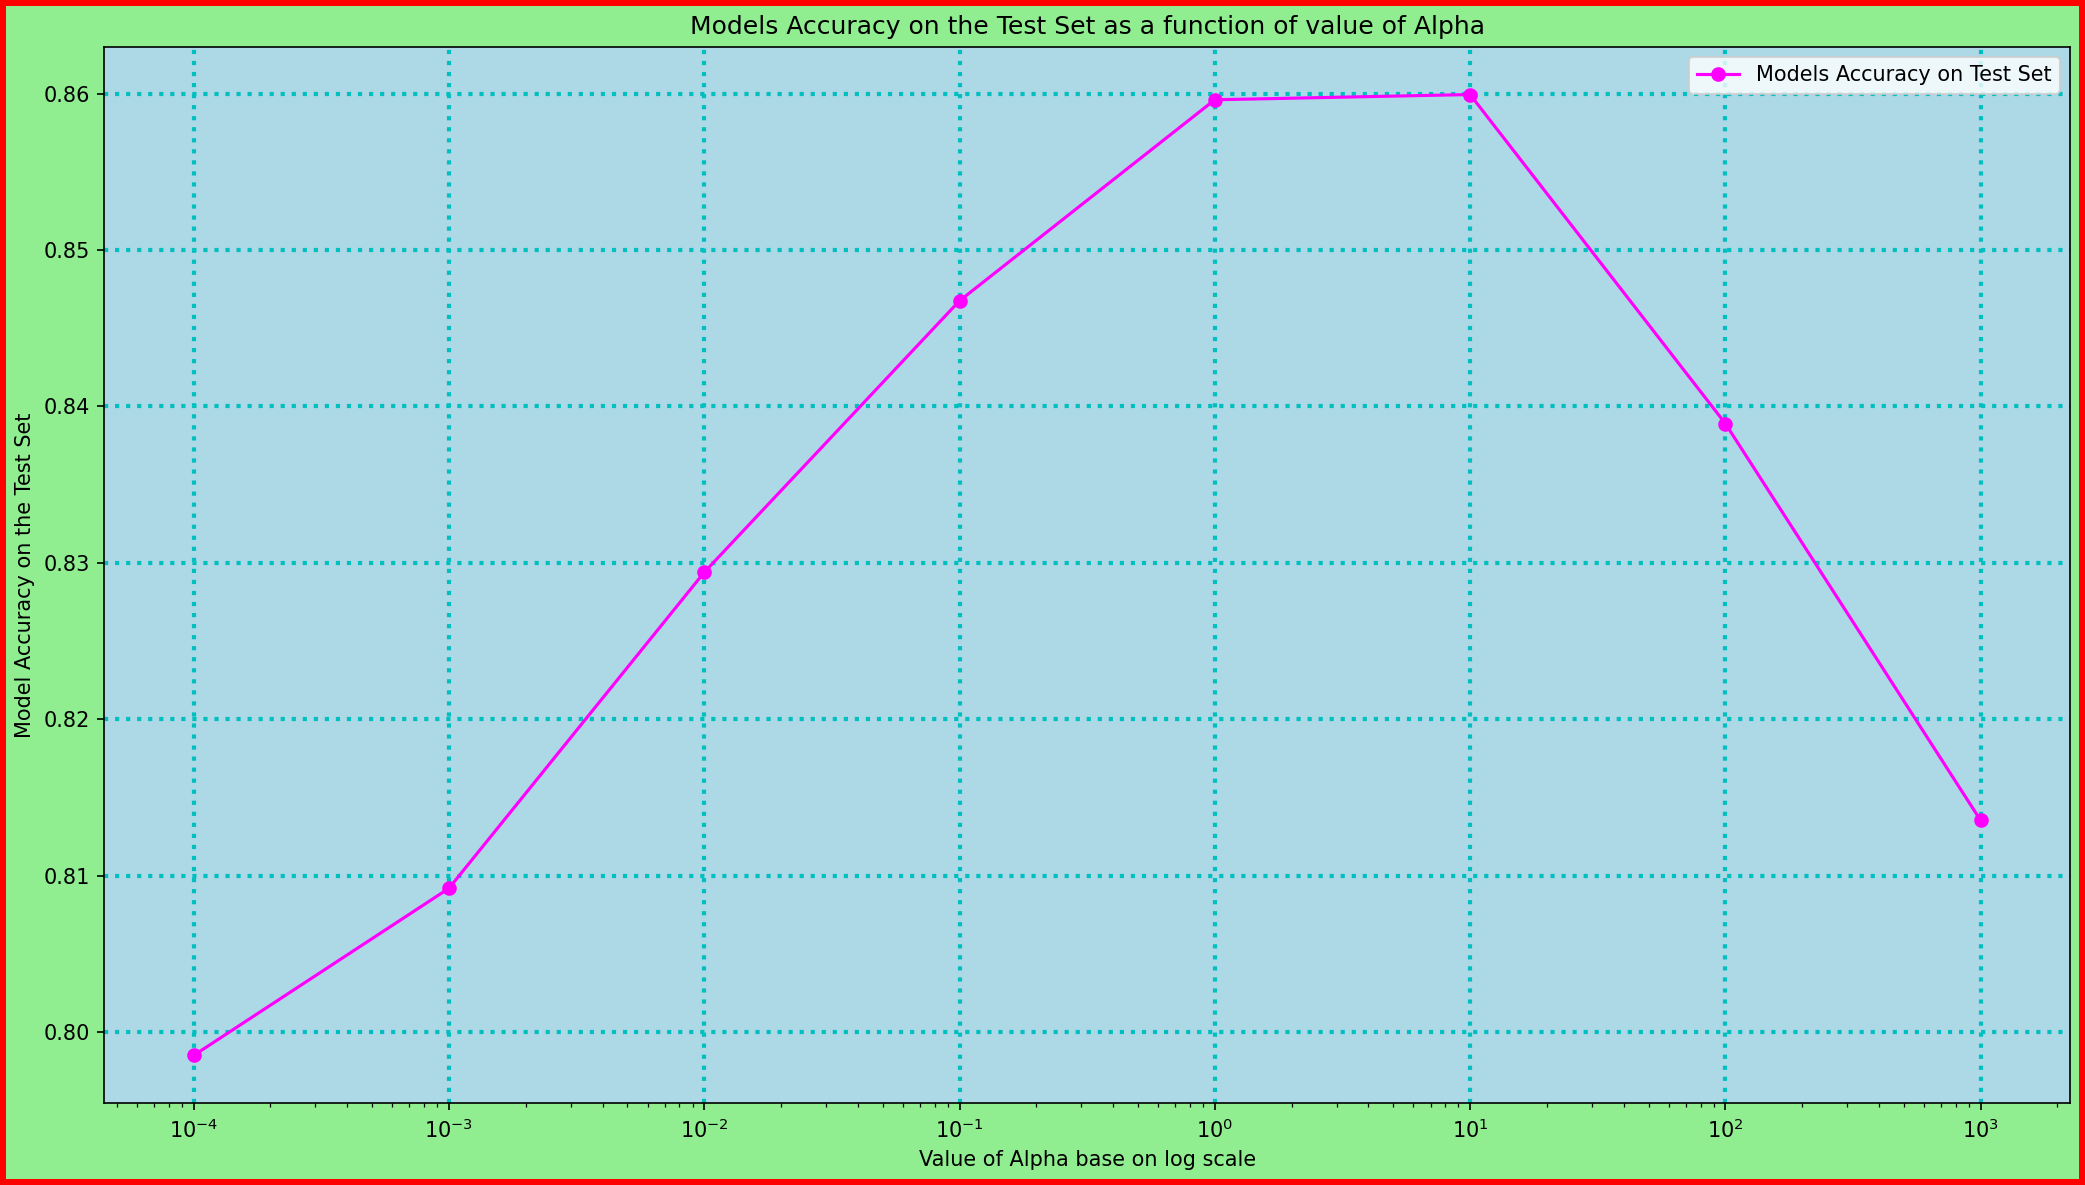

In [304]:
#### List of alpha values for testing purpose ####
alphas = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]
#### Initializing an empty list to store accuracy for each alpha value ####
accuracies = []  

for alpha in alphas:

    #### Initializing confusion matrix variables ####
    True_Positive = 0
    False_Positive = 0
    True_Negative = 0
    False_Negative = 0
    #### Total number of unique words in the vocabulary ####
    vocab_length = len(vocab)

    #### Classifying positive test documents ####
    for doc in positive_test:
        prediction_positive = multinomial_log(doc, word_counts_positive, word_counts_negative, total_words_positive, total_words_negative, alpha, vocab_length)
        if prediction_positive == 1:
            True_Positive += 1  #### Predicted Review is positive and Actual review is positive  
        else:
            False_Negative += 1  #### Predicted Review is negative and Actual review is positive 

    #### Classifying negative test documents ####
    for doc in negative_test:
        prediction_negative = multinomial_log(doc, word_counts_positive, word_counts_negative, total_words_positive, total_words_negative, alpha, vocab_length)
        if prediction_negative == 0:
            True_Negative += 1   #### Predicted Review is negative and Actual review is negative 
        else:
            False_Positive += 1   #### Predicted Review is positive and Actual review is negative 

    #### Accuracy, Precision, Recall calculation ####
    accuracy  = (True_Positive + True_Negative) / (True_Positive + True_Negative + False_Positive + False_Negative)
    #### Adding the calculated accuracy value to the Accuracies List ####
    accuracies.append(accuracy)
    #### Display the alpha value and corresponding Accuracy ####
    print(f"Value of Alpha = {alpha}: Accuracy of the Model = {accuracy:.6f}") 

#### Plotting the Models accuracy on the test set as a function of value of alpha ####
import matplotlib.pyplot as plt
plt.figure(figsize=(14,8), dpi = 150.0, facecolor = 'lightgreen', edgecolor = 'red', linewidth = 5.0, frameon = True, layout = 'tight')
plt.plot(alphas, accuracies, marker='o', color='magenta', label = 'Models Accuracy on Test Set')
plt.xticks(alphas)
plt.xscale('log')  # log scale on x-axis
plt.xlabel('Value of Alpha base on log scale')
plt.ylabel('Model Accuracy on the Test Set')
plt.title('Models Accuracy on the Test Set as a function of value of Alpha')
plt.grid(True, axis = 'both', color = 'c',linestyle = ':', linewidth = 2.0, alpha = 1.0)
plt.legend()
plt.gca().set_facecolor('lightblue')

plt.savefig('Q2 Accuracy of the Model for various alpha values.pdf')

plt.show()

In [306]:
#### Question 3 ####

#### Calling the dataset loading function with 1.0 as the parameter ####
#### for using 100% of the training set and 100% of the test set   ####
positive_train, negative_train, vocab = utils.load_training_set(1.0,1.0)
positive_test, negative_test = utils.load_test_set(1.0,1.0)

In [308]:
print(len(positive_train))
print(len(negative_train))
print(len(vocab))
print(len(positive_test))
print(len(negative_test))

15000
15000
81407
15000
15000


In [310]:
##### Priori probability calculation : Pr(yi) = N(yi)/N ####
N_Positive = len(positive_train) #### N(Positive) = Number of documents belonging to positive class ####
N_Negative = len(negative_train) #### N(Negative) = Number of documents belonging to negative class ####
N = N_Positive + N_Negative #### N is the total number of documents available ####

print("Number of documents belonging to Positive class with 100% of the training set:", N_Positive)
print("Number of documents belonging to Negative class with 100% of the training set:", N_Negative)
print("Total number of documents with 100% of the training set:", N)
print("Number of unique words in the vocabulary |V| with 100% of the training set:", len(vocab))

Prior_Probability_Positive = N_Positive/N
Prior_Probability_Negative = N_Negative/N

print("\nPrior Probability Positive (Percentage of documents of Positive Class) with 100% of the training set:", (Prior_Probability_Positive * 100),"%")
print("Prior Probability Negative (Percentage of documents of Negative Class) with 100% of the training set:", (Prior_Probability_Negative * 100),"%")

Number of documents belonging to Positive class with 100% of the training set: 15000
Number of documents belonging to Negative class with 100% of the training set: 15000
Total number of documents with 100% of the training set: 30000
Number of unique words in the vocabulary |V| with 100% of the training set: 81407

Prior Probability Positive (Percentage of documents of Positive Class) with 100% of the training set: 50.0 %
Prior Probability Negative (Percentage of documents of Negative Class) with 100% of the training set: 50.0 %


In [312]:
#### Calculation of n(wk, yi) - frequency of each word per class ####
#### Creation of empty dictionaries to store word frequency per class
word_counts_positive = {}
word_counts_negative = {}

### n(word, positive) - frequency of word in the positive class
for doc in positive_train:
    for word in doc:
        if word in vocab:
            word_counts_positive[word] = word_counts_positive.get(word, 0) + 1  
            
#### get() method returns the value of specified key in the dictionary
#### get(key, value) - key to be searched in dictionary, value to be returned if key is not found

### n(word, negative) - frequency of word in the negative class
for doc in negative_train:
    for word in doc:
        if word in vocab:
            word_counts_negative[word] = word_counts_negative.get(word, 0) + 1


total_words_positive = sum(word_counts_positive.values())
total_words_negative = sum(word_counts_negative.values())

#### values() method retrieves all word counts from the dictionary, sum() adds them together

print("Total Number of words that appear in documents of class Positive with 100% of the training set:", total_words_positive)
print("Total Number of words that appear in documents of class Negative with 100% of the training set:", total_words_negative)

Total Number of words that appear in documents of class Positive with 100% of the training set: 924917
Total Number of words that appear in documents of class Negative with 100% of the training set: 965073


In [318]:
#### Initializing confusion matrix variables ####
True_Positive = 0
False_Positive = 0
True_Negative = 0
False_Negative = 0

#### The value of Alpha that resulted in highest Accuracy according to result from Question No 2 (Alpha = 10) ####
alpha = 10
#### Total number of unique words in the vocabulary ####
vocab_length = len(vocab)

#### Classifying positive test documents ####
for doc in positive_test:
    prediction_positive = multinomial_log(doc, word_counts_positive, word_counts_negative, total_words_positive, total_words_negative, alpha, vocab_length)
    if prediction_positive == 1:
        True_Positive += 1  #### Predicted Review is positive and Actual review is positive  
    else:
        False_Negative += 1  #### Predicted Review is negative and Actual review is positive 

#### Classifying negative test documents ####
for doc in negative_test:
    prediction_negative = multinomial_log(doc, word_counts_positive, word_counts_negative, total_words_positive, total_words_negative, alpha, vocab_length)
    if prediction_negative == 0:
        True_Negative += 1   #### Predicted Review is negative and Actual review is negative 
    else:
        False_Positive += 1   #### Predicted Review is positive and Actual review is negative 

#### Accuracy, Precision, Recall calculation ####
accuracy  = (True_Positive + True_Negative) / (True_Positive + True_Negative + False_Positive + False_Negative)
precision = True_Positive / (True_Positive + False_Positive)
recall    = True_Positive / (True_Positive + False_Negative)

#### Printing the Confusion Matrix Resulting from the experiment with 100% of Training Set and 100% of Test Set ####
print("Impact of the training set size on the performance of the Multinomial Naive Bayes algorithm with Laplace Smoothing and Log-Probabilities")
print("Confusion Matrix resulting from the experiment with 100% of Training Set and 100% of Test Set")
print(f"True Positive:  {True_Positive}  False Negative: {False_Negative}")
print(f"False Positive: {False_Positive}  True Negative: {True_Negative}")

#### Printing the Accuracy of the model, precision and recall with 100% of Training Set and 100% of Test Set ####
print("\nResults of the Model with 100% of Training Set and 100% of Test Set")
print(f"Accuracy of the model:  {accuracy:.6f}")
print(f"Precision: {precision:.6f}")
print(f"Recall:    {recall:.6f}")

Impact of the training set size on the performance of the Multinomial Naive Bayes algorithm with Laplace Smoothing and Log-Probabilities
Confusion Matrix resulting from the experiment with 100% of Training Set and 100% of Test Set
True Positive:  12340  False Negative: 2660
False Positive: 1345  True Negative: 13655

Results of the Model with 100% of Training Set and 100% of Test Set
Accuracy of the model:  0.866500
Precision: 0.901717
Recall:    0.822667


In [320]:
#### Question 4 ####

#### Calling the dataset loading function with 0.3 as the parameter for using 30% of the training set ####
#### Calling the dataset loading function with 1.0 as the parameter for using 100% of the testing set   ####
positive_train, negative_train, vocab = utils.load_training_set(0.3,0.3)
positive_test, negative_test = utils.load_test_set(1.0,1.0)

In [322]:
print(len(positive_train))
print(len(negative_train))
print(len(vocab))
print(len(positive_test))
print(len(negative_test))

4458
4587
42111
15000
15000


In [328]:
##### Priori probability calculation : Pr(yi) = N(yi)/N ####
N_Positive = len(positive_train) #### N(Positive) = Number of documents belonging to positive class ####
N_Negative = len(negative_train) #### N(Negative) = Number of documents belonging to negative class ####
N = N_Positive + N_Negative #### N is the total number of documents available ####

print("Number of documents belonging to Positive class with 30% of the training set:", N_Positive)
print("Number of documents belonging to Negative class with 30% of the training set:", N_Negative)
print("Total number of documents with 30% of the training set:", N)
print("Number of unique words in the vocabulary |V| with 30% of the training set:", len(vocab))

Prior_Probability_Positive = N_Positive/N
Prior_Probability_Negative = N_Negative/N

print("\nPrior Probability Positive (Percentage of documents of Positive Class) with 30% of the training set:", (Prior_Probability_Positive * 100),"%")
print("Prior Probability Negative (Percentage of documents of Negative Class) with 30% of the training set:", (Prior_Probability_Negative * 100),"%")

Number of documents belonging to Positive class with 30% of the training set: 4458
Number of documents belonging to Negative class with 30% of the training set: 4587
Total number of documents with 30% of the training set: 9045
Number of unique words in the vocabulary |V| with 30% of the training set: 42111

Prior Probability Positive (Percentage of documents of Positive Class) with 30% of the training set: 49.28689883913764 %
Prior Probability Negative (Percentage of documents of Negative Class) with 30% of the training set: 50.71310116086235 %


In [330]:
#### Calculation of n(wk, yi) - frequency of each word per class ####
#### Creation of empty dictionaries to store word frequency per class
word_counts_positive = {}
word_counts_negative = {}

### n(word, positive) - frequency of word in the positive class
for doc in positive_train:
    for word in doc:
        if word in vocab:
            word_counts_positive[word] = word_counts_positive.get(word, 0) + 1  
            
#### get() method returns the value of specified key in the dictionary
#### get(key, value) - key to be searched in dictionary, value to be returned if key is not found

### n(word, negative) - frequency of word in the negative class
for doc in negative_train:
    for word in doc:
        if word in vocab:
            word_counts_negative[word] = word_counts_negative.get(word, 0) + 1


total_words_positive = sum(word_counts_positive.values())
total_words_negative = sum(word_counts_negative.values())

#### values() method retrieves all word counts from the dictionary, sum() adds them together

print("Total Number of words that appear in documents of class Positive with 30% of the training set:", total_words_positive)
print("Total Number of words that appear in documents of class Negative with 30% of the training set:", total_words_negative)

Total Number of words that appear in documents of class Positive with 30% of the training set: 279067
Total Number of words that appear in documents of class Negative with 30% of the training set: 293505


In [336]:
#### Initializing confusion matrix variables ####
True_Positive = 0
False_Positive = 0
True_Negative = 0
False_Negative = 0

#### The value of Alpha that resulted in highest Accuracy according to result from Question No 2 (Alpha = 10) ####
alpha = 10
#### Total number of unique words in the vocabulary ####
vocab_length = len(vocab)

#### Classifying positive test documents ####
for doc in positive_test:
    prediction_positive = multinomial_log(doc, word_counts_positive, word_counts_negative, total_words_positive, total_words_negative, alpha, vocab_length)
    if prediction_positive == 1:
        True_Positive += 1  #### Predicted Review is positive and Actual review is positive  
    else:
        False_Negative += 1  #### Predicted Review is negative and Actual review is positive 

#### Classifying negative test documents ####
for doc in negative_test:
    prediction_negative = multinomial_log(doc, word_counts_positive, word_counts_negative, total_words_positive, total_words_negative, alpha, vocab_length)
    if prediction_negative == 0:
        True_Negative += 1   #### Predicted Review is negative and Actual review is negative 
    else:
        False_Positive += 1   #### Predicted Review is positive and Actual review is negative 

#### Accuracy, Precision, Recall calculation ####
accuracy  = (True_Positive + True_Negative) / (True_Positive + True_Negative + False_Positive + False_Negative)
precision = True_Positive / (True_Positive + False_Positive)
recall    = True_Positive / (True_Positive + False_Negative)

#### Printing the Confusion Matrix Resulting from the experiment with 100% of Training Set and 100% of Test Set ####
print("Impact of the smaller training set size (30%) on the performance of the Multinomial Naive Bayes algorithm with Laplace Smoothing and Log-Probabilities")
print("Confusion Matrix resulting from the experiment with 30% of Training Set and 100% of Test Set")
print(f"True Positive:  {True_Positive}  False Negative: {False_Negative}")
print(f"False Positive: {False_Positive}  True Negative: {True_Negative}")

#### Printing the Accuracy of the model, precision and recall with 100% of Training Set and 100% of Test Set ####
print("\nResults of the Model with 30% of Training Set and 100% of Test Set")
print(f"Accuracy of the model:  {accuracy:.6f}")
print(f"Precision: {precision:.6f}")
print(f"Recall:    {recall:.6f}")

Impact of the smaller training set size (30%) on the performance of the Multinomial Naive Bayes algorithm with Laplace Smoothing and Log-Probabilities
Confusion Matrix resulting from the experiment with 30% of Training Set and 100% of Test Set
True Positive:  11847  False Negative: 3153
False Positive: 1210  True Negative: 13790

Results of the Model with 30% of Training Set and 100% of Test Set
Accuracy of the model:  0.854567
Precision: 0.907329
Recall:    0.789800


In [338]:
#### Question 6 ####

#### Calling the dataset loading function with (0.1, 0.5) as the parameter ####
#### for using 10% of the positive training set and 50% of the negative training set ####
#### Calling the dataset loading function with 1.0 as the parameter for using 100% of the testing set   ####
positive_train, negative_train, vocab = utils.load_training_set(0.1,0.5)
positive_test, negative_test = utils.load_test_set(1.0,1.0)

In [340]:
print(len(positive_train))
print(len(negative_train))
print(len(vocab))
print(len(positive_test))
print(len(negative_test))

1528
7564
42394
15000
15000


In [346]:
##### Priori probability calculation : Pr(yi) = N(yi)/N ####
N_Positive = len(positive_train) #### N(Positive) = Number of documents belonging to positive class ####
N_Negative = len(negative_train) #### N(Negative) = Number of documents belonging to negative class ####
N = N_Positive + N_Negative #### N is the total number of documents available ####

print("Number of documents belonging to Positive class with 10% of the positive training set:", N_Positive)
print("Number of documents belonging to Negative class with 50% of the negative training set:", N_Negative)
print("Total number of documents with 10% of positive training set and 50% of negative training set:", N)
print("Number of unique words in the vocabulary |V| with 10% of positive training set and 50% of negative training set:", len(vocab))

Prior_Probability_Positive = N_Positive/N
Prior_Probability_Negative = N_Negative/N

print("\nPrior Probability Positive (Percentage of documents of Positive Class) with 10% of positive training set:", (Prior_Probability_Positive * 100),"%")
print("Prior Probability Negative (Percentage of documents of Negative Class) with 50% of negative training set:", (Prior_Probability_Negative * 100),"%")

Number of documents belonging to Positive class with 10% of the positive training set: 1528
Number of documents belonging to Negative class with 50% of the negative training set: 7564
Total number of documents with 10% of positive training set and 50% of negative training set: 9092
Number of unique words in the vocabulary |V| with 10% of positive training set and 50% of negative training set: 42394

Prior Probability Positive (Percentage of documents of Positive Class) with 10% of positive training set: 16.80598328200616 %
Prior Probability Negative (Percentage of documents of Negative Class) with 50% of negative training set: 83.19401671799385 %


In [348]:
#### Calculation of n(wk, yi) - frequency of each word per class ####
#### Creation of empty dictionaries to store word frequency per class
word_counts_positive = {}
word_counts_negative = {}

### n(word, positive) - frequency of word in the positive class
for doc in positive_train:
    for word in doc:
        if word in vocab:
            word_counts_positive[word] = word_counts_positive.get(word, 0) + 1  
            
#### get() method returns the value of specified key in the dictionary
#### get(key, value) - key to be searched in dictionary, value to be returned if key is not found

### n(word, negative) - frequency of word in the negative class
for doc in negative_train:
    for word in doc:
        if word in vocab:
            word_counts_negative[word] = word_counts_negative.get(word, 0) + 1


total_words_positive = sum(word_counts_positive.values())
total_words_negative = sum(word_counts_negative.values())

#### values() method retrieves all word counts from the dictionary, sum() adds them together

print("Total Number of words that appear in documents of class Positive with 10% of the positive training set:", total_words_positive)
print("Total Number of words that appear in documents of class Negative with 50% of the negative training set:", total_words_negative)

Total Number of words that appear in documents of class Positive with 10% of the positive training set: 94349
Total Number of words that appear in documents of class Negative with 50% of the negative training set: 485055


In [354]:
#### Initializing confusion matrix variables ####
True_Positive = 0
False_Positive = 0
True_Negative = 0
False_Negative = 0

#### The value of Alpha that resulted in highest Accuracy according to result from Question No 2 (Alpha = 10) ####
alpha = 10
#### Total number of unique words in the vocabulary ####
vocab_length = len(vocab)

#### Classifying positive test documents ####
for doc in positive_test:
    prediction_positive = multinomial_log(doc, word_counts_positive, word_counts_negative, total_words_positive, total_words_negative, alpha, vocab_length)
    if prediction_positive == 1:
        True_Positive += 1  #### Predicted Review is positive and Actual review is positive  
    else:
        False_Negative += 1  #### Predicted Review is negative and Actual review is positive 

#### Classifying negative test documents ####
for doc in negative_test:
    prediction_negative = multinomial_log(doc, word_counts_positive, word_counts_negative, total_words_positive, total_words_negative, alpha, vocab_length)
    if prediction_negative == 0:
        True_Negative += 1   #### Predicted Review is negative and Actual review is negative 
    else:
        False_Positive += 1   #### Predicted Review is positive and Actual review is negative 

#### Accuracy, Precision, Recall calculation ####
accuracy  = (True_Positive + True_Negative) / (True_Positive + True_Negative + False_Positive + False_Negative)
precision = True_Positive / (True_Positive + False_Positive)
recall    = True_Positive / (True_Positive + False_Negative)

#### Printing the Confusion Matrix Resulting from the experiment with 100% of Training Set and 100% of Test Set ####
print("Impact of the unbalanced training dataset on the performance of the Multinomial Naive Bayes algorithm with Laplace Smoothing and Log-Probabilities")
print("Confusion Matrix resulting from the experiment with Unbalanced Training Set (10% of available positive and 50% of available negative training instances) and 100% of Test Set")
print(f"True Positive:  {True_Positive}  False Negative: {False_Negative}")
print(f"False Positive: {False_Positive}  True Negative: {True_Negative}")

#### Printing the Accuracy of the model, precision and recall with 100% of Training Set and 100% of Test Set ####
print("\nResults of the Model with Unbalanced Training Set (10% of available positive and 50% of available negative training instances) and 100% of Test Set")
print(f"Accuracy of the model:  {accuracy:.6f}")
print(f"Precision: {precision:.6f}")
print(f"Recall:    {recall:.6f}")

Impact of the unbalanced training dataset on the performance of the Multinomial Naive Bayes algorithm with Laplace Smoothing and Log-Probabilities
Confusion Matrix resulting from the experiment with Unbalanced Training Set (10% of available positive and 50% of available negative training instances) and 100% of Test Set
True Positive:  44  False Negative: 14956
False Positive: 28  True Negative: 14972

Results of the Model with Unbalanced Training Set (10% of available positive and 50% of available negative training instances) and 100% of Test Set
Accuracy of the model:  0.500533
Precision: 0.611111
Recall:    0.002933
